Title: RL_data_analysis_NM.ipynb

Purpose: Analyse the basic residual load output from the SEM

Author: Onno Nennecke on 17.04.2025 Modified: 24.02.2026

Input data: 

- Adjusted Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 52B 'SMARD'
    run            (ESM_run) <U12 48B 'hist'
  * ESM_run        (ESM_run) <U23 92B 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    demand         (ESM_run, time) float64 29kB 1.097e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    rsds           (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    tas            (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    tasmax         (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    wind_off_prod  (ESM_run, time) float64 29kB 12.51 10.33 ... 61.19 69.34
    wind_on_prod   (ESM_run, time) float64 29kB 298.8 591.6 ... 534.3 529.0
    solar_prod     (ESM_run, time) float64 29kB 17.08 7.759 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 29kB 328.4 609.7 ... 618.5 647.4
    Netto          (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    Residual_load  (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8

In [3]:
ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 193, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 ... -8.134 -9.41
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.636e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... 3.01 4.735
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... 38.66 48.7
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 ... -7.047 -8.388
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 ... -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 31.44 148.9
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 71.95 87.86
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 113.4 316.1
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 ... -1.32e+03
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 ... 1.32e+03

In [15]:
# Not important, just check how the new model changed the thresholds
'''ds_not_CESM = ds.where(~ds.ESM_run.str.startswith("CESM2_LE2") & (ds.ESM_run != 'SMARD_hist'), drop=True)
ds_not_CESM.load()

wind = ds_not_CESM['wind_off_prod'] + ds_not_CESM['wind_on_prod']
wind_on = ds_not_CESM['wind_on_prod']
wind_off = ds_not_CESM['wind_off_prod']
solar = ds_not_CESM['solar_prod']
total = ds_not_CESM['total_prod']
demand = ds_not_CESM['demand']
res_load = ds_not_CESM['Residual_load']

# Thresholds
wind_off_thresh = np.quantile(wind_off.values.flatten(), 0.05)
wind_on_thresh = np.quantile(wind_on.values.flatten(), 0.05)
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)'''

Wind:  39.965735909423
Solar:  35.19706606071225
Total:  191.0327725178088
Demand:  1545.6936624921852
Residual Load:  1303.09784585557


In [4]:
# All data
wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
wind_on = ts_datasets['wind_on_prod']
wind_off = ts_datasets['wind_off_prod']
solar = ts_datasets['solar_prod']
total = ts_datasets['total_prod']
demand = ts_datasets['demand']
res_load = ts_datasets['Residual_load']

# Thresholds
wind_off_thresh = np.quantile(wind_off.values.flatten(), 0.05)
wind_on_thresh = np.quantile(wind_on.values.flatten(), 0.05)
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# Pull out the doy coordinate for x-axis
x = ts_datasets['doy']

# Compute the mean cycle (averaged over runs & years)
mean_wind_on  = wind_on.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off  = wind_off.groupby(x).mean(dim=['ESM_run','time'])
mean_wind  = wind.groupby(x).mean(dim=['ESM_run','time'])
mean_solar = solar.groupby(x).mean(dim=['ESM_run','time'])
mean_total = total.groupby(x).mean(dim=['ESM_run','time'])
mean_demand = demand.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load = res_load.groupby(x).mean(dim=['ESM_run','time'])

# Compute the CMIP mean cycle 
wind_CMIP6 = ds_CMIP6['wind_off_prod'] + ds_CMIP6['wind_on_prod']
wind_on_CMIP6 = ds_CMIP6['wind_on_prod']
wind_off_CMIP6 = ds_CMIP6['wind_off_prod']
solar_CMIP6 = ds_CMIP6['solar_prod']
total_CMIP6 = ds_CMIP6['total_prod']
demand_CMIP6 = ds_CMIP6['demand']
res_load_CMIP6 = ds_CMIP6['Residual_load']


mean_wind_CMIP6  = wind_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_on_CMIP6  = wind_on_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off_CMIP6  = wind_off_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_solar_CMIP6 = solar_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_total_CMIP6 = total_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_demand_CMIP6 = demand_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load_CMIP6 = res_load_CMIP6.groupby(x).mean(dim=['ESM_run','time'])

# Compute the ERA5 mean cycle 
wind_ERA5 = ds_ERA5['wind_off_prod'] + ds_ERA5['wind_on_prod']
wind_on_ERA5 = ds_ERA5['wind_on_prod']
wind_off_ERA5 = ds_ERA5['wind_off_prod']
solar_ERA5 = ds_ERA5['solar_prod']
total_ERA5 = ds_ERA5['total_prod']
demand_ERA5 = ds_ERA5['demand']
res_load_ERA5 = ds_ERA5['Residual_load']

mean_wind_ERA5  = wind_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_on_ERA5  = wind_on_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off_ERA5  = wind_off_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_solar_ERA5 = solar_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_total_ERA5 = total_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_demand_ERA5 = demand_ERA5.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load_ERA5 = res_load_ERA5.groupby(x).mean(dim=['ESM_run','time'])

# Compute the SMARD mean cycle ---
wind_SMARD  = ds_SMARD['wind_off_prod'] + ds_SMARD['wind_on_prod']
wind_on_SMARD = ds_SMARD['wind_on_prod']
wind_off_SMARD = ds_SMARD['wind_off_prod']
solar_SMARD = ds_SMARD['solar_prod']
total_SMARD = ds_SMARD['total_prod']
demand_SMARD = ds_SMARD['demand']
res_load_SMARD = ds_SMARD['Residual_load']

mean_wind_SMARD  = wind_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_on_SMARD  = wind_on_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off_SMARD  = wind_off_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_solar_SMARD = solar_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_total_SMARD = total_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_demand_SMARD = demand_SMARD.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load_SMARD = res_load_SMARD.groupby(x).mean(dim=['ESM_run','time'])


In [5]:
# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)

Wind:  20.595222912441848
Solar:  32.532469404435254
Total:  159.73389521479572
Demand:  1527.1970477025945
Residual Load:  1319.138650687668


In [ ]:
# Old with old model
'''# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)'''

Wind:  10.95362048715713
Solar:  -0.900976283496567
Total:  98.30511891544901
Demand:  1546.218580381004
Residual Load:  1398.1161147066591


In [6]:
ds_ERA5

# Make a dataframe of all ERA5 days on which the Residual_load is higher than res_load_thresh
df_ERA5 = (
    ds_ERA5
    .where(ds_ERA5['Residual_load'] >= res_load_thresh, drop=True)
    .to_dataframe()
    .reset_index()
)
df_ERA5

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,total_prod,Netto,Residual_load,crs,gridtype,ESM,run,country,period,doy
0,ERA5_hist_week,2015-01-19,-0.172751,1522.045899,3.050853,39.650494,0.020719,1.482230,6.818393,42.608840,...,119.898145,-1402.147755,1402.147755,4326,lonlat,ERA5_week,hist,9.0,week,19
1,ERA5_hist_week,2015-01-20,-0.079220,1520.892623,2.085351,32.618126,0.028827,1.183755,11.898247,15.267802,...,81.598682,-1439.293940,1439.293940,4326,lonlat,ERA5_week,hist,9.0,week,20
2,ERA5_hist_week,2015-01-21,-0.830337,1530.150794,3.534396,43.403721,-0.681516,0.688586,9.616098,61.715518,...,146.278176,-1383.872619,1383.872619,4326,lonlat,ERA5_week,hist,9.0,week,21
3,ERA5_hist_week,2015-01-22,-0.471668,1525.730817,4.097617,33.203106,-0.387075,0.762105,8.922608,130.375018,...,194.251275,-1331.479542,1331.479542,4326,lonlat,ERA5_week,hist,9.0,week,22
4,ERA5_hist_week,2015-01-23,-0.772133,1529.433626,3.405123,29.340708,-0.654838,0.157332,15.464886,41.666809,...,99.872880,-1429.560746,1429.560746,4326,lonlat,ERA5_week,hist,9.0,week,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,ERA5_hist_week,2024-12-12,1.195686,1505.156642,1.897472,25.497252,1.318758,2.369368,9.364542,9.635955,...,63.463159,-1441.693483,1441.693483,4326,lonlat,ERA5_week,hist,9.0,week,346
156,ERA5_hist_week,2024-12-13,0.059812,1519.178053,3.832063,32.850933,0.179918,1.542387,10.044613,67.465920,...,137.235207,-1381.942847,1381.942847,4326,lonlat,ERA5_week,hist,9.0,week,347
157,ERA5_hist_week,2024-12-26,2.858030,1484.570552,3.596641,26.542210,3.031038,4.995277,16.057925,46.601788,...,113.071477,-1371.499075,1371.499075,4326,lonlat,ERA5_week,hist,9.0,week,360
158,ERA5_hist_week,2024-12-27,0.706743,1511.195532,2.513451,32.226482,1.191884,3.729366,5.657123,18.745118,...,86.696924,-1424.498608,1424.498608,4326,lonlat,ERA5_week,hist,9.0,week,361


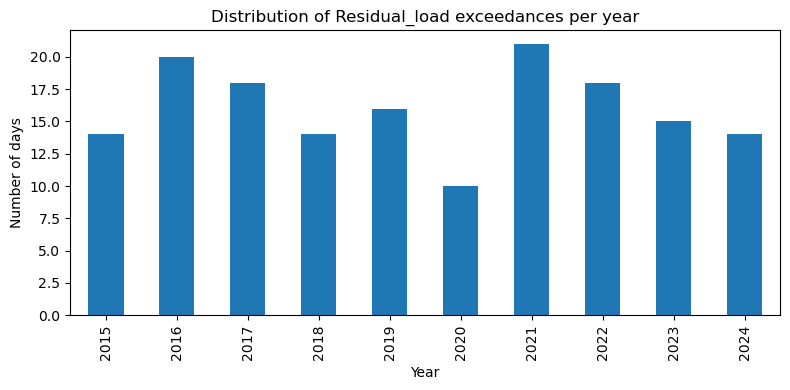

In [7]:
df_ERA5['year'] = df_ERA5['time'].dt.year
counts_per_year = df_ERA5.groupby('year').size()

plt.figure(figsize=(8, 4))
counts_per_year.plot(kind='bar')

plt.xlabel('Year')
plt.ylabel('Number of days')
plt.title('Distribution of Residual_load exceedances per year')

plt.tight_layout()
plt.show()


In [8]:
# For new model output
print(float(wind.max()))
print(float(solar.max()))
print(float(total.max()))
print(float(demand.max()))
print(float(res_load.max()))

1743.0216004079998
563.6943436228736
2080.075628025767
1702.5083202511773
1583.1053720383402


In [ ]:
# For old model output
'''print(float(wind.max()))
print(float(solar.max()))
print(float(total.max()))
print(float(demand.max()))
print(float(res_load.max()))

1743.0216004079998
395.14008036413867
1971.1250671749492
1702.5083202511773
1654.9069514283508

'''

1743.0216004079998
395.14008036413867
1971.1250671749492
1702.5083202511773
1654.9069514283508


In [9]:
def plot_winter_panel_with_months(ax, data, CMIP6_mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title, nr_days_in_a_bin = 1, shift_days=182, SMARD = False):
    # --- Define histogram bins ---
    bin_size = int(np.floor(365/nr_days_in_a_bin))
    # print('Number of bins: ', bin_size)
    x_bins = np.linspace(x.min().values, x.max().values, bin_size)
    #    y‐bins: choose from 0 to a bit above your max production
    y_max = 2000# float(total.max())
    y_bins = np.linspace(0, y_max, 1710)
    
    
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles ----
    doy_mc = CMIP6_mean_cycle['doy'].values
    cmip6_vals   = CMIP6_mean_cycle.values
    era5_vals = ERA5_mean_cycle.values
    smr_vals  = SMARD_mean_cycle.values

    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], cmip6_vals[order],   c="#000000", lw=1.5, label='CMIP6 mean')
    ax.plot(doy_mc_shift[order], era5_vals[order], c='#0072B2', lw=1, label='ERA5 mean')
    if SMARD:
        ax.plot(doy_mc_shift[order], smr_vals[order],  c="#CC5A99", lw=1, label='SMARD mean')

    # ---- finalize axis limits & title ----
    ax.set_title(title, loc='left')
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    # ax.set_xlabel('Shifted Day of Year (winter at center)')

    # ---- correct month‐name ticks on shifted axis ----
    # 1) true DOY for each month
    month_starts = {
        'Jan':   1,   'Feb':  32,  'Mar':  60,
        'Apr':  91,   'May': 121,  'Jun': 152,
        'Jul': 182,   'Aug': 213,  'Sep': 244,
        'Oct': 274,   'Nov': 305,  'Dec': 335
    }
    # 2) shift & wrap them
    xticks = [((d + shift_days - 1) % 365) + 1 for d in month_starts.values()]
    # 3) apply to axis
    ax.set_xticks(xticks)
    ax.set_xticklabels(month_starts.keys(), rotation=90) # , ha='right'

    # ax.legend()
    return h


In [10]:
def plot_winter_panel_with_months_new(ax, data, mean_cycle, title, nr_days_in_a_bin = 1, shift_days=182):
    # --- Define histogram bins ---
    bin_size = int(np.floor(365/nr_days_in_a_bin))
    # print('Number of bins: ', bin_size)
    x_bins = np.linspace(x.min().values, x.max().values, bin_size)
    #    y‐bins: choose from 0 to a bit above your max production
    y_max = 2000# float(total.max())
    y_bins = np.linspace(0, y_max, 1710)
    
    
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles ----
    doy_mc = mean_cycle['doy'].values
    mean_vals   = mean_cycle.values


    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], mean_vals[order],   c="#000000", lw=1.5, label='Mean')

    # ---- finalize axis limits & title ----
    ax.set_title(title, loc='left')
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    # ax.set_xlabel('Shifted Day of Year (winter at center)')

    # ---- correct month‐name ticks on shifted axis ----
    # 1) true DOY for each month
    month_starts = {
        'Jan':   1,   'Feb':  32,  'Mar':  60,
        'Apr':  91,   'May': 121,  'Jun': 152,
        'Jul': 182,   'Aug': 213,  'Sep': 244,
        'Oct': 274,   'Nov': 305,  'Dec': 335
    }
    # 2) shift & wrap them
    xticks = [((d + shift_days - 1) % 365) + 1 for d in month_starts.values()]
    # 3) apply to axis
    ax.set_xticks(xticks)
    ax.set_xticklabels(month_starts.keys(), rotation=90) # , ha='right'

    # ax.legend()
    return h


In [11]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 14,         # base font size
    'axes.labelsize': 16,    # x/y labels
    'axes.titlesize': 18,    # axes titles (if used)
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 16,   # legend text
    'figure.titlesize': 20,  # figure title (if used)
})

# --- Define histogram bins ---
nr_days_in_a_bin = 1
bin_size = int(np.floor(365/nr_days_in_a_bin))
print('Number of bins: ', bin_size)
x_bins = np.linspace(x.min().values, x.max().values, bin_size)
#    y‐bins: choose from 0 to a bit above your max production
y_max = 2000# float(total.max())
y_bins = np.linspace(0, y_max, 1710)
def plot_winter_panel_old_DOY(ax, data, mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title, shift_days=182):
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles as plain numpy arrays ----
    doy_mc = mean_cycle['doy'].values
    mc_vals   = mean_cycle.values
    era5_vals = ERA5_mean_cycle.values
    smr_vals  = SMARD_mean_cycle.values

    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], mc_vals[order],   c='k', lw=2, label='mean')
    ax.plot(doy_mc_shift[order], era5_vals[order], c='w', lw=1, label='ERA5')
    ax.plot(doy_mc_shift[order], smr_vals[order],  c='r', lw=1, label='SMARD')

    # ---- finalize ----
    ax.set_title(title)
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    ax.set_xlabel('Shifted day of year (winter at center)')
    ax.legend()
    return h


def plot_winter_panel_old_not_shifted(ax, data, mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title):
    # Flatten to 1D for histogram
    X = np.tile(x.values, data.shape[0])
    Y = data.values.flatten()
    # 2D histogram with log scaling
    h = ax.hist2d(X, Y, bins=[x_bins, y_bins],
                  norm=LogNorm(), cmap='inferno_r')
    # Mark low‐end outliers (e.g. bottom 0.1 percentile)
    low = np.percentile(Y, 0.1)
    high = np.percentile(Y, 99.9)
    mask = (Y < low) | (Y > high)
    # ax.scatter(X[mask], Y[mask], s=3, c='b', alpha=0.4)
    # Mean winter cycle
    ax.plot(mean_cycle['doy'], mean_cycle, c='k', lw=2)
    # ERA5 mean winter cycle
    ax.plot(mean_cycle['doy'], ERA5_mean_cycle, c='w', lw=1)
    # SMARD mean winter cycle
    ax.plot(mean_cycle['doy'], SMARD_mean_cycle, c='r', lw=1)
    ax.set_title(title)
    ax.set_xlim(x_bins[0], x_bins[-1])
    ax.set_xlabel('Day of year')
    return h

Number of bins:  365


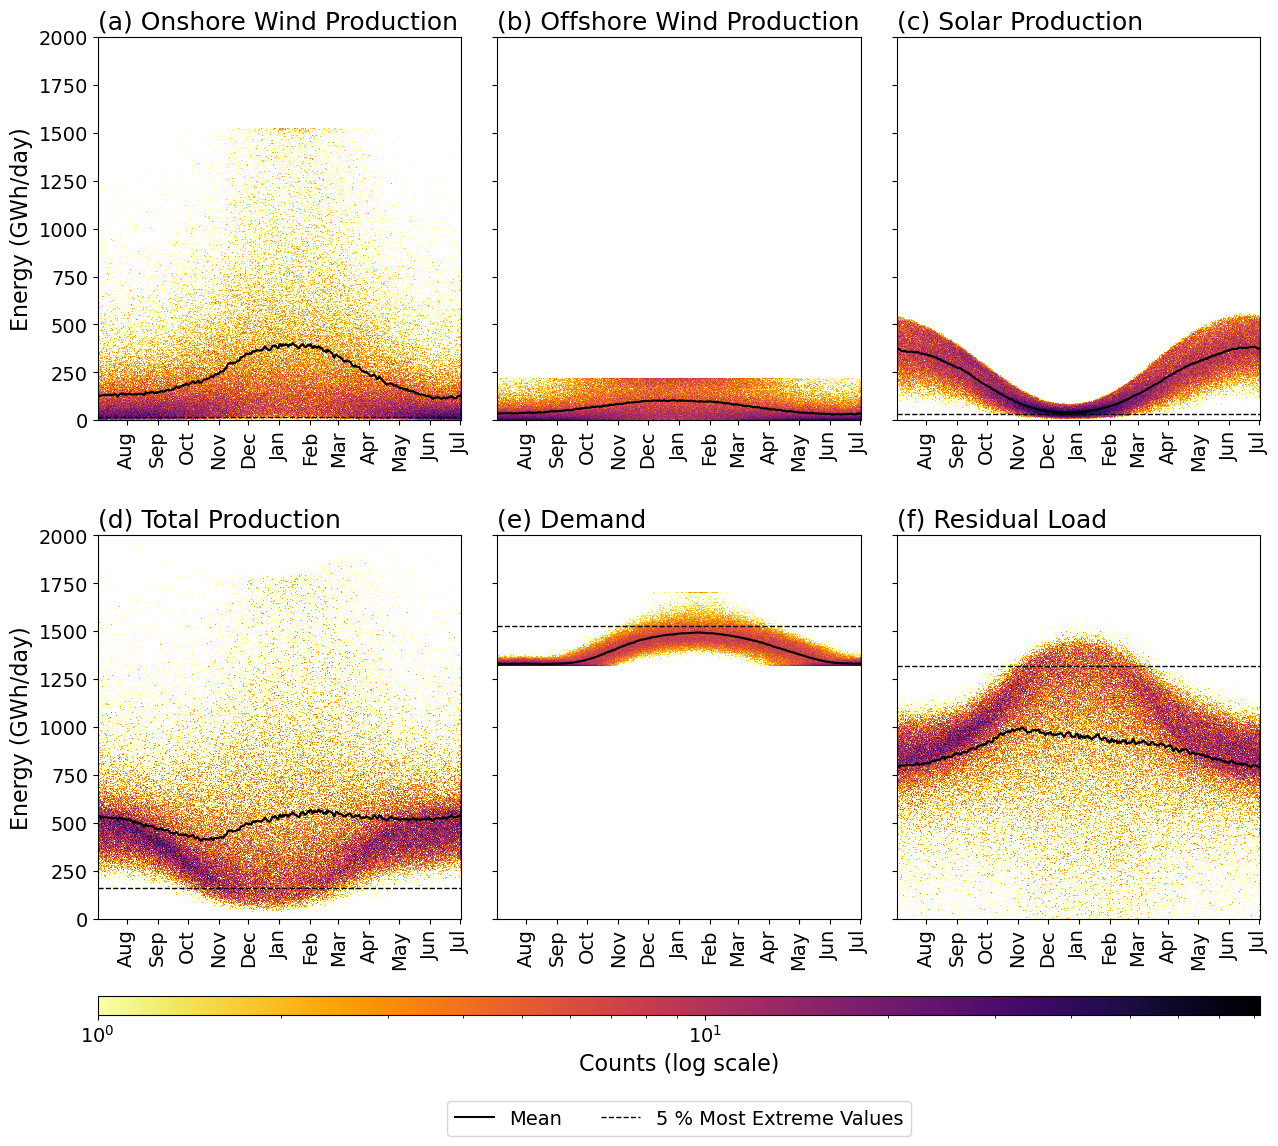

In [13]:
fig = plt.figure(figsize=(15, 14))

height_ratios = [1, 0.3, 1, 0.2, 0.05, 0.2, 0.06]
gs = GridSpec(nrows=7, ncols=3,
              height_ratios=height_ratios,
              hspace=0.0,
              wspace=0.1)

# --- create top row, sharing y-axis across the row ---
axes_top = []
# first top axis
ax0 = fig.add_subplot(gs[0, 0])
axes_top.append(ax0)
# share y with the first top axis for the remaining top axes
axes_top.append(fig.add_subplot(gs[0, 1], sharey=ax0))
axes_top.append(fig.add_subplot(gs[0, 2], sharey=ax0))

# --- create bottom row, sharing y-axis across that row ---
axes_bottom = []
ax2_0 = fig.add_subplot(gs[2, 0])
axes_bottom.append(ax2_0)
axes_bottom.append(fig.add_subplot(gs[2, 1], sharey=ax2_0))
axes_bottom.append(fig.add_subplot(gs[2, 2], sharey=ax2_0))

# example calls to your plotting function (use your function as before)
h1 = plot_winter_panel_with_months_new(axes_top[0], wind_on, mean_wind_on, '(a) Onshore Wind Production', nr_days_in_a_bin=1)
h2 = plot_winter_panel_with_months_new(axes_top[1], wind_off, mean_wind_off, '(b) Offshore Wind Production', nr_days_in_a_bin=1)
h3 = plot_winter_panel_with_months_new(axes_top[2], solar, mean_solar, '(c) Solar Production', nr_days_in_a_bin=1)
h4 = plot_winter_panel_with_months_new(axes_bottom[0], total, mean_total, '(d) Total Production', nr_days_in_a_bin=1)
h5 = plot_winter_panel_with_months_new(axes_bottom[1], demand, mean_demand, '(e) Demand', nr_days_in_a_bin=1)
h6 = plot_winter_panel_with_months_new(axes_bottom[2], res_load, mean_res_load, '(f) Residual Load', nr_days_in_a_bin=1)

# show y-label only on left-most axes (since the row shares y)
axes_top[0].set_ylabel('Energy (GWh/day)')
axes_bottom[0].set_ylabel('Energy (GWh/day)')

# hide y-tick labels on the other axes in the same row to avoid duplicate labels
for ax in axes_top[1:]:
    ax.tick_params(labelleft=False)
for ax in axes_bottom[1:]:
    ax.tick_params(labelleft=False)

# colorbar (row 4)
cax = fig.add_subplot(gs[4, :])
cb = plt.colorbar(h3[3], cax=cax, orientation='horizontal')
cb.set_label('Counts (log scale)')

# legend row (row 6)
legend_ax = fig.add_subplot(gs[6, :])
legend_ax.axis('off')

# thresholds and legend handling
axes_top[0].axhline(wind_on_thresh, ls='--', color='k', lw=1, label='5 % Most Extreme Values')
axes_top[1].axhline(wind_off_thresh, ls='--', color='k', lw=1)
axes_top[2].axhline(solar_thresh, ls='--', color='k', lw=1)
axes_bottom[0].axhline(total_thresh, ls='--', color='k', lw=1)
axes_bottom[1].axhline(demand_thresh, ls='--', color='k', lw=1)
axes_bottom[2].axhline(res_load_thresh, ls='--', color='k', lw=1)

handles, labels = axes_top[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize='medium')

# Save plot
plt.savefig('/home/onennecke/Code/Figures/2D_hist_6_plts.png', bbox_inches='tight', dpi=300)

plt.show()


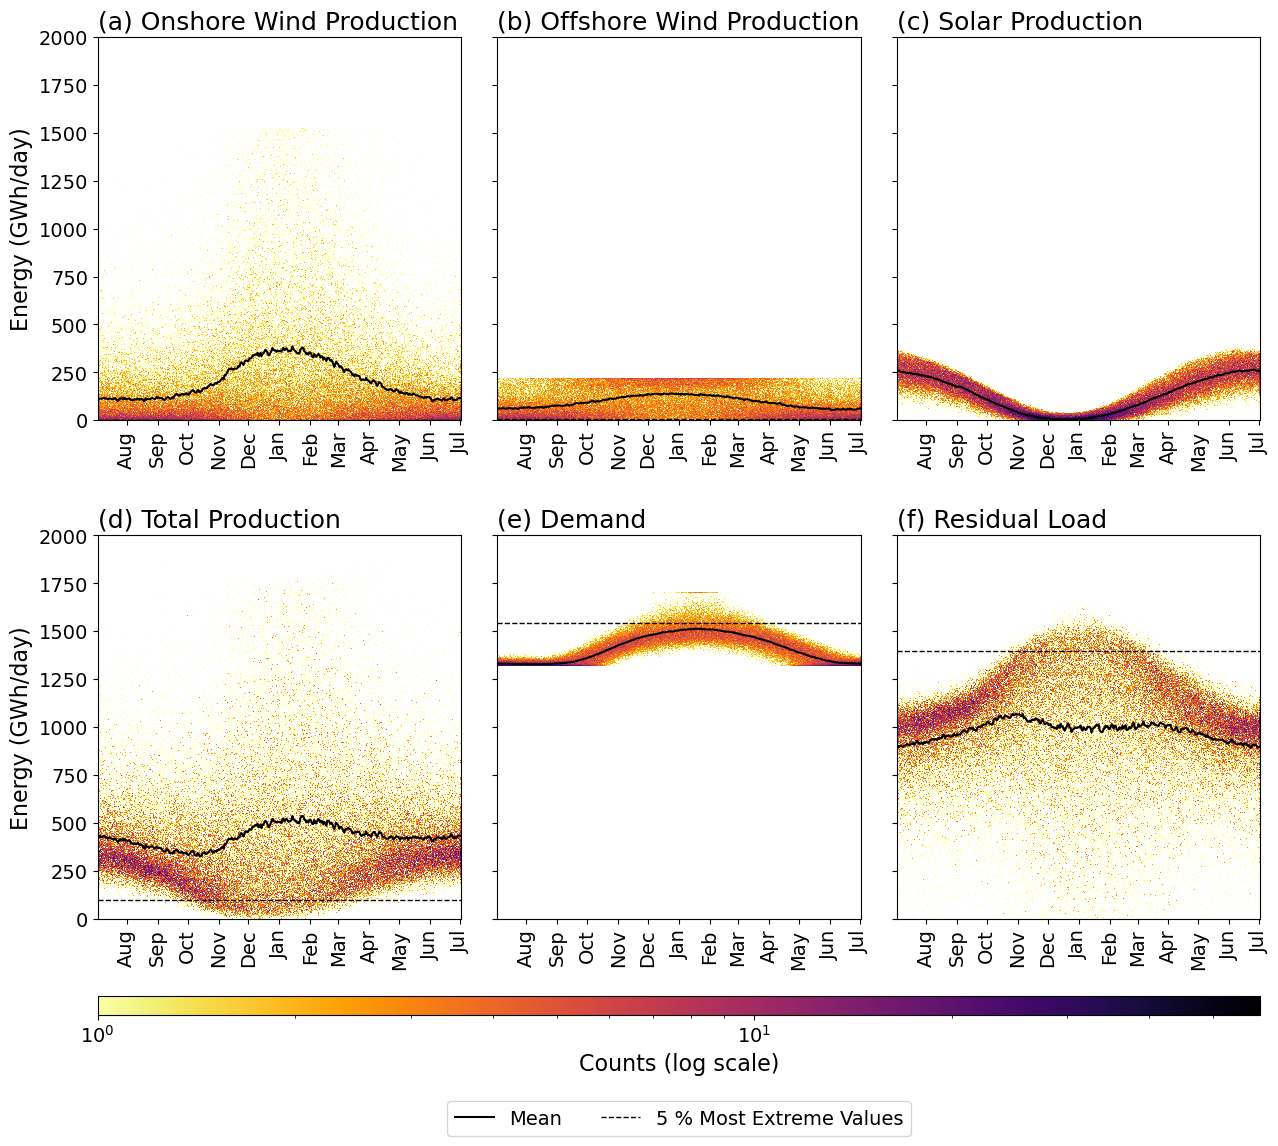

In [ ]:
# Old plot for comparison

'''fig = plt.figure(figsize=(15, 14))

height_ratios = [1, 0.3, 1, 0.2, 0.05, 0.2, 0.06]
gs = GridSpec(nrows=7, ncols=3,
              height_ratios=height_ratios,
              hspace=0.0,
              wspace=0.1)

# --- create top row, sharing y-axis across the row ---
axes_top = []
# first top axis
ax0 = fig.add_subplot(gs[0, 0])
axes_top.append(ax0)
# share y with the first top axis for the remaining top axes
axes_top.append(fig.add_subplot(gs[0, 1], sharey=ax0))
axes_top.append(fig.add_subplot(gs[0, 2], sharey=ax0))

# --- create bottom row, sharing y-axis across that row ---
axes_bottom = []
ax2_0 = fig.add_subplot(gs[2, 0])
axes_bottom.append(ax2_0)
axes_bottom.append(fig.add_subplot(gs[2, 1], sharey=ax2_0))
axes_bottom.append(fig.add_subplot(gs[2, 2], sharey=ax2_0))

# example calls to your plotting function (use your function as before)
h1 = plot_winter_panel_with_months_new(axes_top[0], wind_on, mean_wind_on, '(a) Onshore Wind Production', nr_days_in_a_bin=1)
h2 = plot_winter_panel_with_months_new(axes_top[1], wind_off, mean_wind_off, '(b) Offshore Wind Production', nr_days_in_a_bin=1)
h3 = plot_winter_panel_with_months_new(axes_top[2], solar, mean_solar, '(c) Solar Production', nr_days_in_a_bin=1)
h4 = plot_winter_panel_with_months_new(axes_bottom[0], total, mean_total, '(d) Total Production', nr_days_in_a_bin=1)
h5 = plot_winter_panel_with_months_new(axes_bottom[1], demand, mean_demand, '(e) Demand', nr_days_in_a_bin=1)
h6 = plot_winter_panel_with_months_new(axes_bottom[2], res_load, mean_res_load, '(f) Residual Load', nr_days_in_a_bin=1)

# show y-label only on left-most axes (since the row shares y)
axes_top[0].set_ylabel('Energy (GWh/day)')
axes_bottom[0].set_ylabel('Energy (GWh/day)')

# hide y-tick labels on the other axes in the same row to avoid duplicate labels
for ax in axes_top[1:]:
    ax.tick_params(labelleft=False)
for ax in axes_bottom[1:]:
    ax.tick_params(labelleft=False)

# colorbar (row 4)
cax = fig.add_subplot(gs[4, :])
cb = plt.colorbar(h3[3], cax=cax, orientation='horizontal')
cb.set_label('Counts (log scale)')

# legend row (row 6)
legend_ax = fig.add_subplot(gs[6, :])
legend_ax.axis('off')

# thresholds and legend handling
axes_top[0].axhline(wind_on_thresh, ls='--', color='k', lw=1, label='5 % Most Extreme Values')
axes_top[1].axhline(wind_off_thresh, ls='--', color='k', lw=1)
axes_top[2].axhline(solar_thresh, ls='--', color='k', lw=1)
axes_bottom[0].axhline(total_thresh, ls='--', color='k', lw=1)
axes_bottom[1].axhline(demand_thresh, ls='--', color='k', lw=1)
axes_bottom[2].axhline(res_load_thresh, ls='--', color='k', lw=1)

handles, labels = axes_top[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize='medium')

# Save plot
plt.savefig('/home/onennecke/Code/Figures/2D_hist_6_plts.png', bbox_inches='tight', dpi=300)

plt.show()
'''

In [14]:
# Dates of the highest mean residual load values
top10_idx = mean_res_load.values.argsort()[-10:][::-1]
for idx in top10_idx:
    doy = mean_res_load['doy'].values[idx]
    val = mean_res_load.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 999.91 at DOY 310 (dates: 11-06)
Value: 996.30 at DOY 309 (dates: 11-05)
Value: 995.39 at DOY 308 (dates: 11-04)
Value: 993.76 at DOY 305 (dates: 11-01)
Value: 989.65 at DOY 311 (dates: 11-07)
Value: 989.29 at DOY 313 (dates: 11-09)
Value: 989.20 at DOY 326 (dates: 11-22)
Value: 988.60 at DOY 306 (dates: 11-02)
Value: 988.37 at DOY 304 (dates: 10-31)
Value: 988.17 at DOY 299 (dates: 10-26)


In [15]:
# Show all doys of extreme residual load days (days above threshold)
extreme_res_load = res_load.where(res_load >= res_load_thresh, drop=True)
unique_extreme_doys_RL = np.unique(extreme_res_load['doy'].values) # Get all unique day-of-year values for extreme res_load days
print(unique_extreme_doys_RL)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  87  90  91  92  93
  94 106 122 282 284 285 286 287 288 289 290 291 292 293 294 295 296 297
 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315
 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333
 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351
 352 353 354 355 356 357 358 359 360 361 362 363 364 365]


In [16]:
# Print dates of the first and last extreme day in the year
date_100 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 100][0])
date_286 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 286][0])
print(f"DOY 100: {date_100.strftime('%Y-%m-%d')}")
print(f"DOY 286: {date_286.strftime('%Y-%m-%d')}")

DOY 100: 2015-04-10
DOY 286: 2015-10-13


In [17]:
# Dates of the highest residual load values
top10_idx = np.argpartition(res_load.values.ravel(), -10)[-10:]
top10_idx = top10_idx[np.argsort(res_load.values.ravel()[top10_idx])[::-1]]  # sort descending
repeated_vector = np.tile(res_load['time'].values, (len(res_load.ESM_run), 1)).ravel()

for idx in top10_idx:
    max_date = repeated_vector[idx]
    print(pd.to_datetime(max_date).strftime('%Y-%m-%d'))

2019-12-16
2020-01-07
2019-01-10
2023-02-02
2020-01-02
2019-12-21
2021-01-18
2020-01-03
2017-12-15
2020-12-30


In [18]:
# Show all doys of extreme demand days (days above threshold)
extreme_demand = demand.where(demand >= demand_thresh, drop=True)
unique_extreme_doys = np.unique(extreme_demand['doy'].values) # Get all unique day-of-year values for extreme demand days
unique_extreme_doys

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 104, 105,
       106, 107, 109, 291, 293, 294, 295, 298, 299, 304, 305, 306, 307,
       308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320,
       321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333,
       334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346,
       347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359,
       360, 361, 362, 363, 364, 365])

In [19]:
# Print dates of the first and last extreme day in the year
100
286
date_100 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 100][0])
date_286 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 286][0])
print(f"DOY 100: {date_100.strftime('%Y-%m-%d')}")
print(f"DOY 286: {date_286.strftime('%Y-%m-%d')}")

DOY 100: 2015-04-10
DOY 286: 2015-10-13


In [20]:
# Dates of the highest mean demand values
top10_idx = mean_total.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_total['doy'].values[idx]
    val = mean_total.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 407.98 at DOY 288 (dates: 10-15)
Value: 410.81 at DOY 287 (dates: 10-14)
Value: 411.92 at DOY 299 (dates: 10-26)
Value: 412.09 at DOY 286 (dates: 10-13)
Value: 412.87 at DOY 295 (dates: 10-22)
Value: 413.70 at DOY 289 (dates: 10-16)
Value: 413.82 at DOY 300 (dates: 10-27)
Value: 414.95 at DOY 292 (dates: 10-19)
Value: 415.28 at DOY 294 (dates: 10-21)
Value: 416.01 at DOY 296 (dates: 10-23)


In [21]:
# Dates of the lowest mean solar production values
top10_idx = mean_solar.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_solar['doy'].values[idx]
    val = mean_solar.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 40.83 at DOY 352 (dates: 12-18)
Value: 41.02 at DOY 356 (dates: 12-22)
Value: 41.07 at DOY 359 (dates: 12-25)
Value: 41.08 at DOY 357 (dates: 12-23)
Value: 41.08 at DOY 358 (dates: 12-24)
Value: 41.10 at DOY 355 (dates: 12-21)
Value: 41.21 at DOY 360 (dates: 12-26)
Value: 41.33 at DOY 354 (dates: 12-20)
Value: 41.46 at DOY 349 (dates: 12-15)
Value: 41.55 at DOY 350 (dates: 12-16)


In [22]:
# Dates of the lowest mean wind production values
top10_idx = mean_wind.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_wind['doy'].values[idx]
    val = mean_wind.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 142.31 at DOY 155 (dates: 06-04)
Value: 143.54 at DOY 154 (dates: 06-03)
Value: 143.60 at DOY 163 (dates: 06-12)
Value: 144.31 at DOY 164 (dates: 06-13)
Value: 145.51 at DOY 168 (dates: 06-17)
Value: 145.93 at DOY 162 (dates: 06-11)
Value: 146.24 at DOY 169 (dates: 06-18)
Value: 146.55 at DOY 178 (dates: 06-27)
Value: 146.61 at DOY 167 (dates: 06-16)
Value: 146.98 at DOY 176 (dates: 06-25)


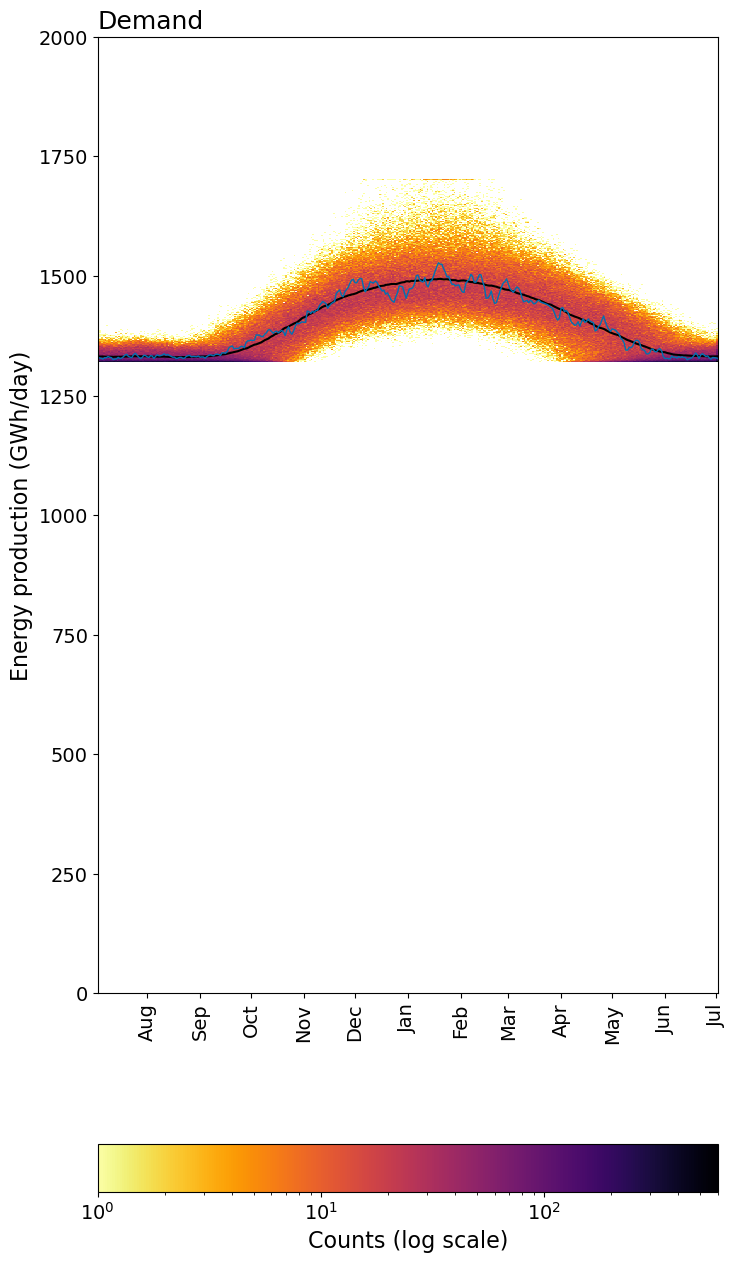

In [23]:
# --- 7) Build the figure with space for a bottom colorbar ---
fig = plt.figure(figsize=(8, 15))
gs = GridSpec(nrows=2, ncols=1,
              height_ratios=[1, 0.05],    # top row for plot, bottom for cbar
              hspace=0.3,                 # vertical space
              wspace=0.2)                 # horizontal space

# create the axis
ax = fig.add_subplot(gs[0, 0])

# plot the demand panel
# h = plot_winter_panel_with_months(ax, wind,  mean_wind_CMIP6, mean_wind_ERA5, mean_wind_SMARD, 'Wind energy production')
# h = plot_winter_panel_with_months(ax, solar, mean_solar_CMIP6, mean_solar_ERA5, mean_solar_SMARD, 'Solar energy production')
# h = plot_winter_panel_with_months(ax, total, mean_total_CMIP6, mean_total_ERA5, mean_total_SMARD, 'Total energy production')
h = plot_winter_panel_with_months(ax, demand, mean_demand_CMIP6, mean_demand_ERA5, mean_demand_SMARD, 'Demand')
# h = plot_winter_panel_with_months(ax, res_load, mean_res_load_CMIP6, mean_res_load_ERA5, mean_res_load_SMARD, 'Residual load', nr_days_in_a_bin=3)

ax.set_ylabel('Energy production (GWh/day)')

# --- 8) Now create a single colorbar axis in the bottom row ---
cax = fig.add_subplot(gs[1, 0])
cb = plt.colorbar(h[3], cax=cax, orientation='horizontal')
cb.set_label('Counts (log scale)')

ax = axes_bottom[1]   # your demand axis
# ax.set_ylim(bottom, top)   # choose bottom/top that definitely include your data
# example:
ax.set_ylim(1250, np.max(demand)*1.05)

# --- 9) Plot the thresholds as a dashed line ---
# ax.axhline(demand_thresh, ls='--', color='k', lw=1)

plt.show()

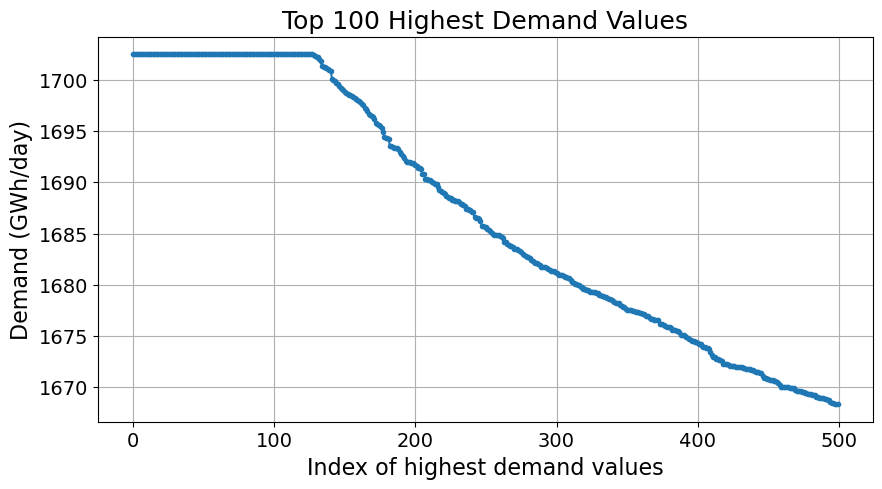

In [23]:
# Sort demand values in descending order to check the highest values
high_dem = np.sort(demand.values.flatten())[::-1]
# Plot the top 100 highest demand values
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(500), high_dem[:500], marker='o', markersize=3)
plt.xlabel("Index of highest demand values")
plt.ylabel("Demand (GWh/day)")
plt.title("Top 100 Highest Demand Values")
plt.grid(True)
plt.show()

In [24]:
import Functions.demand as demand_func
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

# coordinates
countries = ["DE"]
periods = ["hist"]
time = np.arange(5)

# temperature between -15 and 0 °C
temp = xr.DataArray(
    np.linspace(-15, 0, len(time)).reshape(1, 1, -1),
    dims=("country", "period", "time"),
    coords={"country": countries, "period": periods, "time": time},
    name="temp",
)

# input dataset
ds = xr.Dataset({"temp": temp})
print(ds['temp'].values)

tst = demand_func.compute_demand(ds, demand_fit_values.sel(country = 9, period = 'week'))
tst['demand'].values

[[[-15.   -11.25  -7.5   -3.75   0.  ]]]


array([[[1702.50832025, 1658.31672366, 1612.2095058 , 1566.09103113,
         1519.91570287]]])

In [25]:
# convert to pandas Series with MultiIndex (ESM_run, time)
s = demand.to_series()          # Series indexed by (ESM_run, time)

# Example: find all entries whose value matches (approximately) 1702.50832
target = 1702.50832
mask = np.isclose(s.values, target)   # use isclose to avoid float-equality issues
matches = s[mask]

# if matches.empty:
# 	print(f"No entries found with value ≈ {target}")
# else:
	# print matching entries (index shows ESM_run and time)
	# print(matches)
 
# show all rows in notebook output
pd.set_option('display.max_rows', None)
display(matches)

ESM_run                time      
EC-Earth3_r103i1p1f1   2016-02-11    1702.50832
                       2016-02-12    1702.50832
EC-Earth3_r105i1p1f1   2015-02-02    1702.50832
                       2015-02-03    1702.50832
                       2015-02-04    1702.50832
                       2015-02-07    1702.50832
                       2015-02-08    1702.50832
                       2018-02-19    1702.50832
                       2018-02-20    1702.50832
EC-Earth3_r107i1p1f1   2016-01-21    1702.50832
EC-Earth3_r108i1p1f1   2015-02-04    1702.50832
                       2015-02-05    1702.50832
                       2015-02-06    1702.50832
                       2015-02-07    1702.50832
EC-Earth3_r110i1p1f1   2024-02-04    1702.50832
EC-Earth3_r111i1p1f1   2019-01-19    1702.50832
                       2019-01-20    1702.50832
                       2019-01-21    1702.50832
                       2019-01-22    1702.50832
EC-Earth3_r112i1p1f1   2015-01-05    1702.50832
      

In [26]:
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
demand_fit_values.sel(country = 9, period = 'week').load()['heating_max']

<xarray.DataArray 'heating_max' ()> Size: 8B
array(1702.50832025)
Coordinates:
    country  int64 8B 9
    period   <U7 28B 'week'

### Make RL Boxplots

In [27]:
ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 193, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 2.862 -0.3492 ... -8.134 -9.41
    demand         (ESM_run, time) float64 6MB 1.485e+03 1.524e+03 ... 1.636e+03
    sfcWind        (ESM_run, time) float64 6MB 8.056 6.177 6.451 ... 3.01 4.735
    rsds           (ESM_run, time) float32 3MB 13.75 24.11 38.15 ... 38.66 48.7
    tas            (ESM_run, time) float32 3MB 2.114 -0.7924 ... -7.047 -8.388
    tasmax         (ESM_run, time) float32 3MB 4.033 0.7523 ... -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 6MB 122.3 158.7 129.4 ... 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 6MB 731.3 532.7 450.6 ... 31.44 148.9
    solar_prod     (ESM_run, time) float64 6MB 21.42 39.42 66.29 ... 71.95 87.86
    total_prod     (ESM_run, time) float64 6MB 875.0 730.8 646.3 ... 113.4 316.1
    Netto          (ESM_run, time) float64 6MB -609.5 -793.4 ... -1.32e+03
    Residual_load  (ESM_run, time) float64 6MB 609.5 793.4 ... 1.32e+03

In [24]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'Residual_load'
]
df.loc[df['ESM'] == 'ERA5_week', 'ESM'] = 'ERA5'

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 3650).astype(int)
esm_label_map = {esm: f"{esm}\n(n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [25]:
# filter df for only extended winter months (ONDJFM) (based on DOY)
# filter df for only extended winter months (ONDJFM) (based on DOY)
pd.set_option('display.max_rows', 20)

winter_doys = list(range(1, 91)) + list(range(274, 366))  # Jan-Mar and Oct-Dec
df_winter = df[df['doy'].isin(winter_doys)]
df_winter

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Netto,Residual_load,crs,gridtype,ESM,run,country,period,doy,ESM_label
0,ACCESS-CM2_r1i1p1f1,2015-01-01,2.861925,1484.522184,8.056400,13.747292,2.114243,4.032545,122.275802,731.344509,...,-609.480114,609.480114,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,1,ACCESS-CM2\n(n=3)
1,ACCESS-CM2_r1i1p1f1,2015-01-02,-0.349202,1524.221254,6.177364,24.114571,-0.792446,0.752316,158.718630,532.664581,...,-793.414650,793.414650,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,2,ACCESS-CM2\n(n=3)
2,ACCESS-CM2_r1i1p1f1,2015-01-03,-2.721524,1553.436580,6.450903,38.148254,-2.628747,-0.948253,129.363577,450.624754,...,-907.160309,907.160309,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,3,ACCESS-CM2\n(n=3)
3,ACCESS-CM2_r1i1p1f1,2015-01-04,-2.210133,1547.142493,6.054282,31.047712,-1.866056,1.488618,127.516308,331.888714,...,-1028.261459,1028.261459,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4,ACCESS-CM2\n(n=3)
4,ACCESS-CM2_r1i1p1f1,2015-01-05,0.245598,1516.886409,4.147174,21.248137,0.787202,1.800007,50.364626,88.540153,...,-1347.755832,1347.755832,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,5,ACCESS-CM2\n(n=3)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704445,UKESM1-0-LL_r8i1p1f2,2024-12-27,1.156151,1505.645153,5.482421,16.143675,0.702028,2.264657,98.591518,302.033552,...,-1079.526719,1079.526719,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,361,UKESM1-0-LL\n(n=11)
704446,UKESM1-0-LL_r8i1p1f2,2024-12-28,0.950402,1508.186823,5.091629,22.309767,0.430044,1.723065,37.554462,166.876450,...,-1264.246971,1264.246971,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,362,UKESM1-0-LL\n(n=11)
704447,UKESM1-0-LL_r8i1p1f2,2024-12-29,-2.064607,1545.351104,4.773656,16.974064,-2.106223,-0.299865,45.048259,167.084316,...,-1306.702050,1306.702050,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,363,UKESM1-0-LL\n(n=11)
704448,UKESM1-0-LL_r8i1p1f2,2024-12-30,-8.134079,1620.006023,3.009828,38.657166,-7.046603,-3.340998,9.998012,31.436755,...,-1506.619573,1506.619573,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,364,UKESM1-0-LL\n(n=11)


In [34]:
df.head()


,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Netto,Residual_load,crs,gridtype,ESM,run,country,period,doy,ESM_label
0,ACCESS-CM2_r1i1p1f1,2015-01-01,2.861925,1484.522184,8.056400,13.747292,2.114243,4.032545,122.275802,731.344509,...,-609.480114,609.480114,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,1,ACCESS-CM2\n(n=3)
1,ACCESS-CM2_r1i1p1f1,2015-01-02,-0.349202,1524.221254,6.177364,24.114571,-0.792446,0.752316,158.718630,532.664581,...,-793.414650,793.414650,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,2,ACCESS-CM2\n(n=3)
2,ACCESS-CM2_r1i1p1f1,2015-01-03,-2.721524,1553.436580,6.450903,38.148254,-2.628747,-0.948253,129.363577,450.624754,...,-907.160309,907.160309,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,3,ACCESS-CM2\n(n=3)
3,ACCESS-CM2_r1i1p1f1,2015-01-04,-2.210133,1547.142493,6.054282,31.047712,-1.866056,1.488618,127.516308,331.888714,...,-1028.261459,1028.261459,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4,ACCESS-CM2\n(n=3)
4,ACCESS-CM2_r1i1p1f1,2015-01-05,0.245598,1516.886409,4.147174,21.248137,0.787202,1.800007,50.364626,88.540153,...,-1347.755832,1347.755832,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,5,ACCESS-CM2\n(n=3)


In [19]:
183000   *2

366000

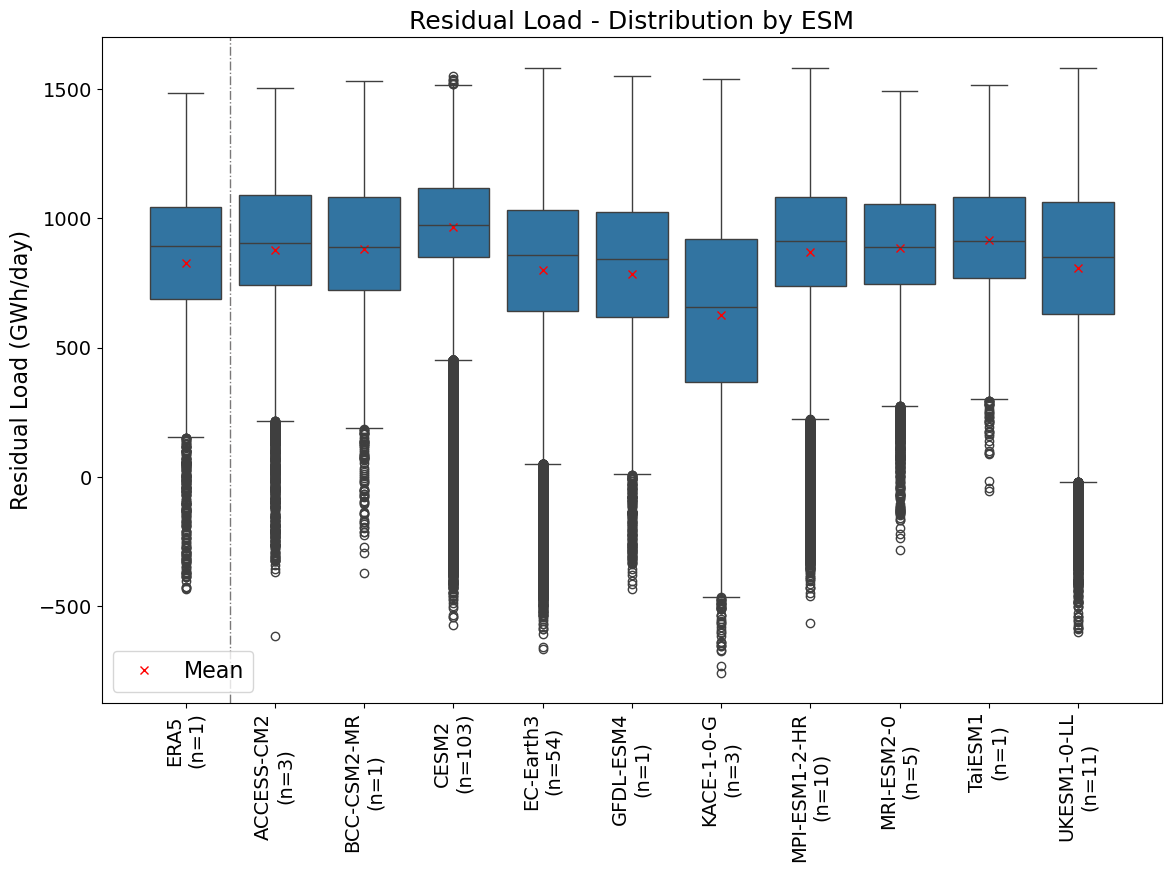

In [26]:
# Single boxplot for variable "res_load"
# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


var = 'Residual_load'
display_var = var  # change if you want a prettier label

# determine order so ERA5 (if present) is first
labels = list(df['ESM_label'].unique())
era5_candidates = [lab for lab in labels if 'ERA5' in str(lab)]
if era5_candidates:
    era5_label = era5_candidates[0]
    order = [era5_label] + [lab for lab in labels if lab != era5_label]
else:
    order = labels

fig, ax = plt.subplots(figsize=(8*3/2, 6*3/2))
sns.boxplot(data=df, x='ESM_label', y=var, order=order, ax=ax)

# plot means at categorical x positions
means = df.groupby('ESM_label')[var].mean().reindex(order)
x_positions = np.arange(len(order))
ax.plot(x_positions, means.values, color='red', marker='x', linestyle='', label='Mean')

# dashed vertical separator between ERA5 (pos 0) and the rest
if len(order) > 1:
    ax.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

# horizontal ERA5_hist mean (if ts_datasets exists and contains ERA5_hist)
if 'ts_datasets' in globals():
    try:
        era5_hist_val = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
        ax.axhline(y=float(era5_hist_val), color='black', linestyle='--', linewidth=1, label='ERA5 mean')
    except Exception:
        # either var not present or ERA5_hist missing — ignore silently
        pass

ax.set_title('Residual Load - Distribution by ESM')
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')

# use units dict if available
# unit = units.get(var, '') if 'units' in globals() else ''
ax.set_ylabel('Residual Load (GWh/day)')

ax.legend(loc='lower left')
plt.tight_layout()
# Save
plt.savefig('/home/onennecke/Code/Figures/RL_bxplt_per_ESM.png', bbox_inches='tight', dpi=300)

plt.show()


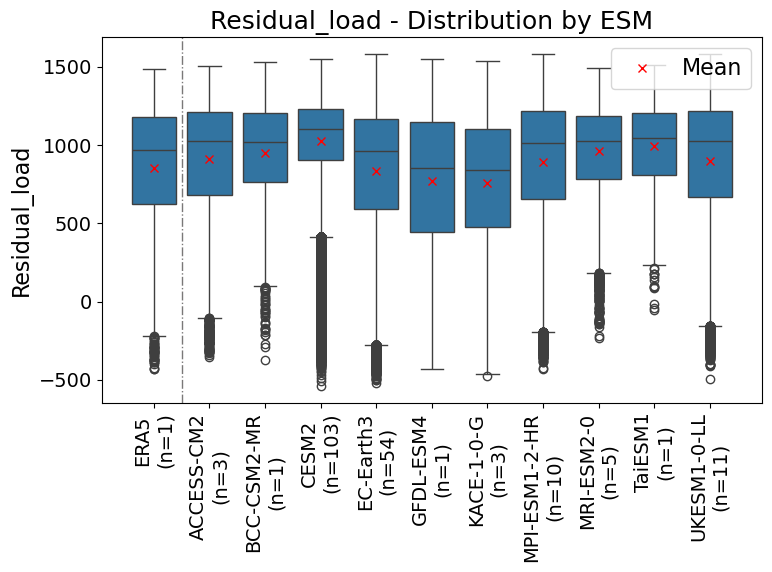

In [27]:
# Same for extended winter months only

# Single boxplot for variable "res_load"

var = 'Residual_load'
display_var = var  # change if you want a prettier label

# determine order so ERA5 (if present) is first
labels = list(df_winter['ESM_label'].unique())
era5_candidates = [lab for lab in labels if 'ERA5' in str(lab)]
if era5_candidates:
    era5_label = era5_candidates[0]
    order = [era5_label] + [lab for lab in labels if lab != era5_label]
else:
    order = labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_winter, x='ESM_label', y=var, order=order, ax=ax)

# plot means at categorical x positions
means = df_winter.groupby('ESM_label')[var].mean().reindex(order)
x_positions = np.arange(len(order))
ax.plot(x_positions, means.values, color='red', marker='x', linestyle='', label='Mean')

# dashed vertical separator between ERA5 (pos 0) and the rest
if len(order) > 1:
    ax.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

# horizontal ERA5_hist mean (if ts_datasets exists and contains ERA5_hist)
if 'ts_datasets' in globals():
    try:
        era5_hist_val = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
        ax.axhline(y=float(era5_hist_val), color='black', linestyle='--', linewidth=1, label='ERA5 mean')
    except Exception:
        # either var not present or ERA5_hist missing — ignore silently
        pass

ax.set_title(f'{display_var} - Distribution by ESM')
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')

# use units dict if available
# unit = units.get(var, '') if 'units' in globals() else ''
# ax.set_ylabel(f'{display_var} ({unit})' if unit else display_var)

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Compare the range of the ERA5 and CMIP Data

In [28]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist') & (ds.ESM_run != 'ERA5_hist_week'),drop=True)
ts_datasets.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 52B 'ERA5_week'
    run            (ESM_run) <U12 48B 'hist'
  * ESM_run        (ESM_run) <U23 92B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB 1.323 3.335 ... 0.7396 0.4142
    demand         (ESM_run, time) float64 29kB 1.504e+03 ... 1.515e+03
    sfcWind        (ESM_run, time) float64 29kB 7.507 11.86 ... 8.049 8.775
    rsds           (ESM_run, time) float32 15kB 30.54 19.51 17.85 ... 26.3 31.92
    tas            (ESM_run, time) float32 15kB 1.771 3.587 ... 1.512 1.194
    tasmax         (ESM_run, time) float32 15kB 3.431 5.871 ... 2.709 3.361
    wind_off_prod  (ESM_run, time) float64 29kB 220.8 221.2 ... 221.1 221.1
    wind_on_prod   (ESM_run, time) float64 29kB 695.5 1.357e+03 ... 783.9 831.2
    solar_prod     (ESM_run, time) float64 29kB 53.72 25.34 ... 48.64 59.86
    total_prod     (ESM_run, time) float64 29kB 970.0 1.603e+03 ... 1.112e+03
    Netto          (ESM_run, time) float64 29kB -533.6 124.7 ... -457.1 -402.6
    Residual_load  (ESM_run, time) float64 29kB 533.6 -124.7 ... 457.1 402.6

In [29]:
df = ts_datasets.to_dataframe().reset_index()   # columns will include ESM_run, time, ESM, run, variables...
df['Residual_load']
df_ERA5 = ds_ERA5.to_dataframe().reset_index()
df_ERA5['Residual_load']

0        533.629549
1       -124.662753
2        290.842862
3        480.368990
4       1092.615313
           ...     
3645    1424.498608
3646    1412.780107
3647     984.912627
3648     457.118721
3649     402.624379
Name: Residual_load, Length: 3650, dtype: float64

In [16]:
era_pday

array([9.99726102e-01, 9.99452205e-01, 9.99178307e-01, ...,
       8.21692687e-04, 5.47795125e-04, 2.73897562e-04])

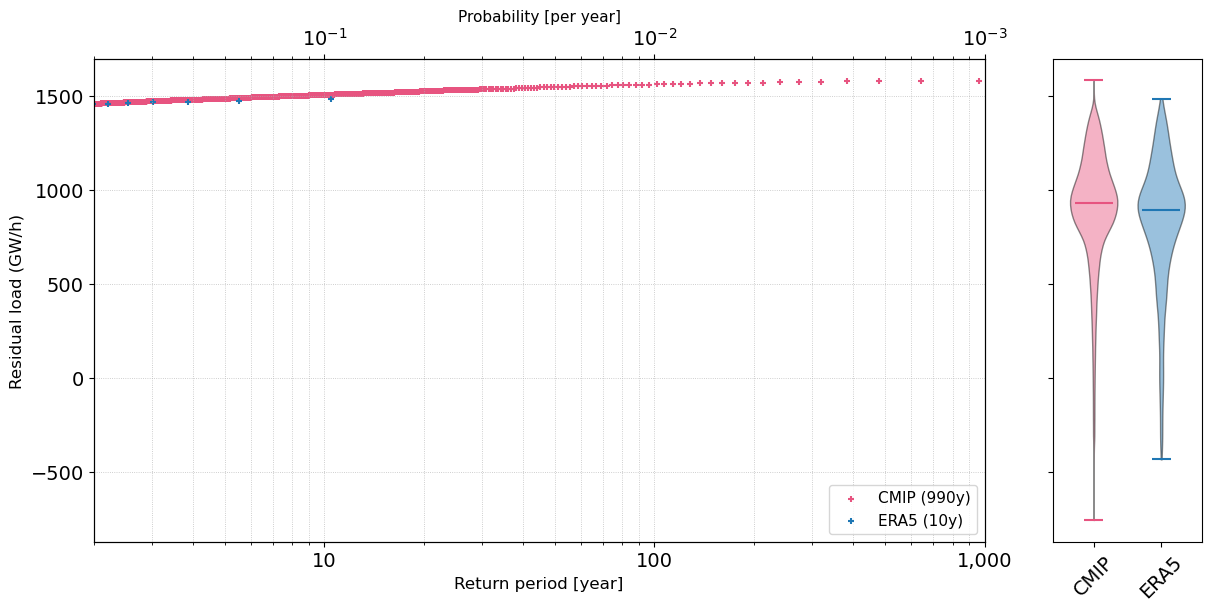

In [39]:
era = df_ERA5['Residual_load'].dropna().values
cmip = df['Residual_load'].dropna().values
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA blue

days_per_year = 365

def empirical_survival(values):
    vals = np.sort(values)
    n = len(vals)
    exceed_prob_day = 1.0 - np.arange(1, n + 1) / (n + 1)   # per-day exceedance prob
    return vals, exceed_prob_day

era_vals, era_pday = empirical_survival(era)
cmip_vals, cmip_pday = empirical_survival(cmip)

# convert per-day -> per-year probabilities and then return period (years)
era_pyear = 1.0 - (1.0 - era_pday) ** days_per_year
cmip_pyear = 1.0 - (1.0 - cmip_pday) ** days_per_year
era_rp = np.where(era_pyear > 0, 1.0 / era_pyear, np.inf)
cmip_rp = np.where(cmip_pyear > 0, 1.0 / cmip_pyear, np.inf)

# plotting masks (clip RPs for readability)
max_rp = 1e3
min_rp = 1.0
era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)
era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

# ---- create figure with two columns: main plot + narrow violin column ----
fig = plt.figure(figsize=(12, 6), constrained_layout=True)
# left: big plot, right: narrow violin column (width ratio 6:1)
gs = fig.add_gridspec(1, 2, width_ratios=[6, 1], wspace=0.06)

ax = fig.add_subplot(gs[0, 0])               # main (left)
ax_violin = fig.add_subplot(gs[0, 1], sharey=ax)  # violin (right), shares y-axis

# --- main plot ---
ax.scatter(cmip_rp_plot, cmip_vals_plot, marker='+',s=24, color=colors[0], label='CMIP (990y)')
ax.scatter(era_rp_plot, era_vals_plot, marker='+', s=24, color=colors[1], label='ERA5 (10y)')

ax.set_xscale('log')
ax.set_xlim(2, max_rp)
ax.set_xlabel('Return period [year]', fontsize=12)
ax.set_ylabel('Residual load (GW/h)', fontsize=12)
# ax.set_title('Return-period plot (empirical) — CMIP vs ERA5', fontsize=14)
ax.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

bottom_ticks = [10, 100, 1000]
ax.set_xticks(bottom_ticks)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# top axis: probability [per year] = 1 / RP
top = ax.twiny()
top.set_xscale('log')
top.set_xlim(ax.get_xlim())
top.set_xticks(bottom_ticks)
top_labels = [r'$10^{-%d}$' % int(np.round(np.log10(rp))) for rp in bottom_ticks]
top.set_xticklabels(top_labels)
top.set_xlabel('Probability [per year]', fontsize=11)

ax.legend(loc='lower right', fontsize=11)

# --- violin plot on the right (separate axis) ---
# We'll show 2 violins: CMIP at x=1, ERA at x=2
data_for_violin = [cmip, era]
positions = [1.0, 2.0]
parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                             widths=0.7, showextrema=False, showmedians=False)
medians = [np.median(cmip), np.median(era)]
maxes = [np.max(cmip), np.max(era)]
min_vals = [np.min(cmip), np.min(era)]

# style violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.45)
    ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.5)
    ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.5)
    ax_violin.hlines(min_vals[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.5)


# tidy violin axis: remove left y-label duplication, minimal x-axis labels
ax_violin.set_xticks(positions)
ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45)
ax_violin.yaxis.set_tick_params(labelleft=False)  # hide violin's y tick labels (main axis shows them)
ax_violin.set_xlim(0.4, 2.6)  # nice padding horizontally
ax_violin.set_ylim(ax.get_ylim())  # ensure identical y-range

# Save the plot
# plt.savefig('/home/onennecke/Code/Figures/Return_period_plot.png', bbox_inches='tight', dpi=300)


plt.show()


In [40]:
RL = ts_datasets['Residual_load']
threshold = np.quantile(RL.values.flatten(), 0.95)
threshold

np.float64(1319.2114680265586)

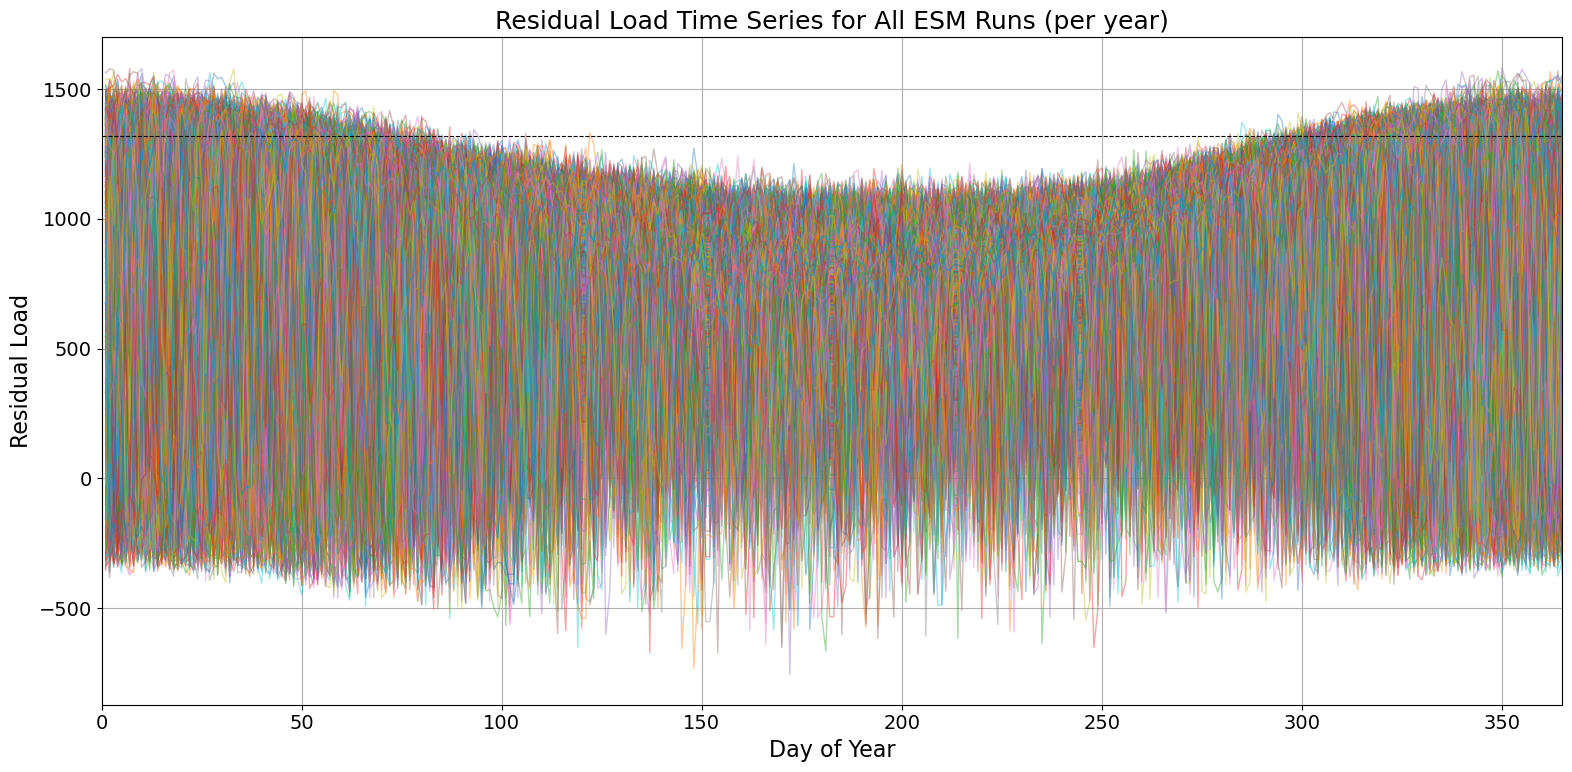

In [43]:
residual = ts_datasets['Residual_load'].compute()
day_of_winter = ts_datasets['doy'].values
winter_years = ts_datasets['time'].dt.year # ts_datasets['winter_year'].values
esm_runs = ts_datasets['ESM_run'].values

plt.figure(figsize=(16, 8))

for i in range(residual.shape[0]):
    for year in np.unique(winter_years):
        mask = winter_years == year
        plt.plot(day_of_winter[mask], residual[i, mask], alpha=0.4, linewidth=1)
        
# Plot some specific ESM runs
plt.plot(day_of_winter[mask], residual[i, mask], alpha=0.4, linewidth=1)

# Make a horizontal line
plt.axhline(threshold, color='black', linestyle='--', linewidth=0.8)
# plt.axhline(threshold_old, color='black', linestyle='--', linewidth=0.8)

plt.xlim(0, 365)

plt.title('Residual Load Time Series for All ESM Runs (per year)')
plt.xlabel('Day of Year')
plt.ylabel('Residual Load')
plt.grid(True)
plt.tight_layout()
plt.show()
